# 01 — Bigram language models

> *Tonight: the simplest possible language model, built twice — once by counting, once by gradient descent — to see they're the same thing.*

Before we build anything transformer-shaped, let's build the humblest possible language model. A **bigram** model predicts the next character using only the single previous character. Nothing else. No memory, no context, just: "given that I just saw `q`, what's most likely next?"

This model will not be impressive. That's the point. By the end of the notebook we'll have used every ingredient we need for the rest of the series — tokenization (we already did it), embeddings, softmax, cross-entropy, gradient descent, sampling — and we'll have a **concrete ceiling** that motivates every improvement to come.


In [1]:
# --- Recap setup from notebook 00 ---------------------------------------
import sys, pathlib, math
ROOT = pathlib.Path.cwd().resolve()
while not (ROOT / "src" / "viz.py").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from src import viz
viz.style()

text = (ROOT / "data" / "tinyshakespeare.txt").read_text(encoding="utf-8")
chars = sorted(set(text))
vocab_size = len(chars)
stoi = {c: i for i, c in enumerate(chars)}
itos = {i: c for c, i in stoi.items()}
data = torch.tensor([stoi[c] for c in text], dtype=torch.long)
n = int(0.9 * len(data))
train_data, val_data = data[:n], data[n:]
print(f"vocab_size={vocab_size}, train tokens={len(train_data):,}, val tokens={len(val_data):,}")


vocab_size=65, train tokens=1,003,854, val tokens=111,540


## Part 1 — Bigrams by counting

Walk through the corpus and, for every adjacent pair `(a, b)`, add 1 to `N[a, b]`. Now `N[a]` is the histogram of what tends to come after character `a`. Normalize each row to sum to 1 and you have an estimate of $P(b \mid a)$.

That's the entire model.


In [2]:
# Count bigrams from the training split.
N = torch.zeros((vocab_size, vocab_size), dtype=torch.long)
prev = train_data[:-1]
nxt = train_data[1:]
# advanced indexing: for each (prev_i, next_i), increment N[prev_i, next_i]
for a, b in zip(prev.tolist(), nxt.tolist()):
    N[a, b] += 1

# Convert to row-normalized probabilities. Add 1 for Laplace smoothing so no
# (a, b) pair has literal zero probability (which would give infinite loss).
P = (N + 1).float()
P = P / P.sum(dim=1, keepdim=True)

print(f"N shape: {tuple(N.shape)}  (rows = previous char, cols = next char)")
print(f"Total bigrams counted: {N.sum().item():,}")


N shape: (65, 65)  (rows = previous char, cols = next char)
Total bigrams counted: 1,003,853


### Visualize the bigram table

Every row is "what tends to follow this character." Look at row `q` — almost all its mass is on `u`. Look at the space row — it goes to uppercase letters (sentence starts) and common word starts. Structure we never explicitly taught the model, but it's already there because the corpus has it.


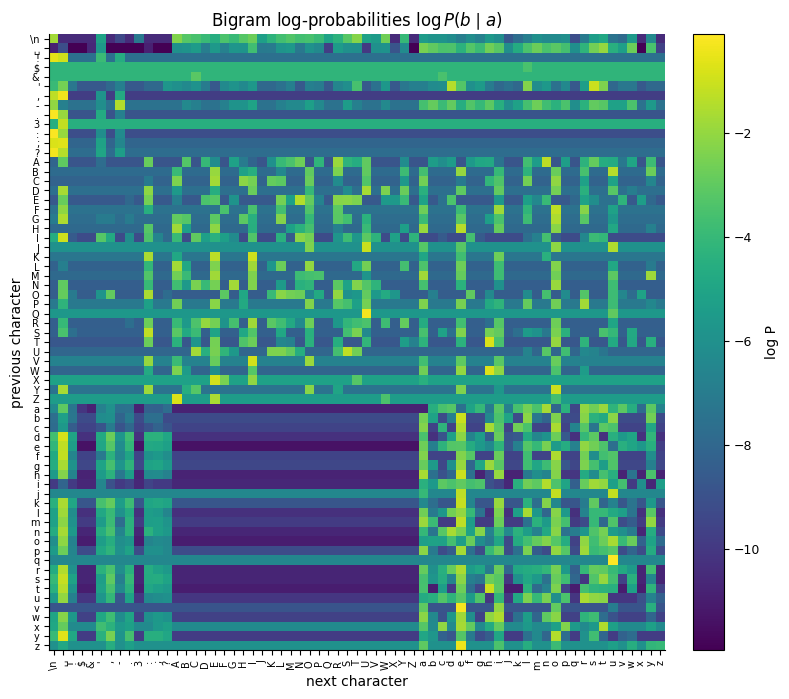

In [3]:
fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(torch.log(P).numpy(), cmap="viridis")
labels = [viz._printable(c) for c in chars]
ax.set_xticks(range(vocab_size)); ax.set_xticklabels(labels, rotation=90, fontsize=7)
ax.set_yticks(range(vocab_size)); ax.set_yticklabels(labels, fontsize=7)
ax.set_xlabel("next character")
ax.set_ylabel("previous character")
ax.set_title("Bigram log-probabilities $\\log P(b\\mid a)$")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="log P")
plt.show()


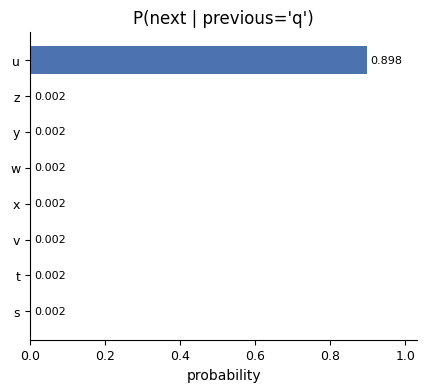

In [4]:
# Zoom in on the famous row: what comes after 'q'?
row_q = P[stoi['q']]
fig, ax = plt.subplots(figsize=(5, 4))
viz.plot_token_probs(row_q, itos, top_k=8, ax=ax, title="P(next | previous='q')")
plt.show()


### Measuring how good this model is: cross-entropy

We evaluate a language model by how much probability it assigns to the text it *actually* sees. Formally we minimize the average **negative log likelihood** (equivalently, **cross-entropy**):

$$\mathcal{L} = -\frac{1}{N} \sum_{t=1}^{N} \log P(x_t \mid x_{t-1})$$

A uniform model over 65 characters would get $\log 65 \approx 4.17$ nats per token. Our count-based bigram should beat that by a healthy margin — but it still only sees one character back.


In [5]:
def bigram_nll(P, data):
    prev = data[:-1]
    nxt = data[1:]
    logP = torch.log(P)
    return -logP[prev, nxt].mean().item()

val_nll = bigram_nll(P, val_data)
uniform_nll = math.log(vocab_size)
print(f"Uniform model NLL:  {uniform_nll:.4f} nats/token")
print(f"Count-based bigram: {val_nll:.4f} nats/token  (on val)")


Uniform model NLL:  4.1744 nats/token
Count-based bigram: 2.4819 nats/token  (on val)


### Sampling from the bigram

Pick any starting character, then at each step draw the next character from the predicted distribution, and repeat. This is exactly how every larger model we build will generate text — the *distribution* will get smarter, but this sampling loop is identical.


In [6]:
def sample_bigram(P, n=200, seed=0):
    g = torch.Generator().manual_seed(seed)
    ix = torch.randint(0, vocab_size, (1,), generator=g).item()
    out = [ix]
    for _ in range(n - 1):
        ix = torch.multinomial(P[ix], num_samples=1, generator=g).item()
        out.append(ix)
    return "".join(itos[i] for i in out)

print("--- sample from count-based bigram (200 chars) ---")
print(sample_bigram(P, n=200, seed=1))


--- sample from count-based bigram (200 chars) ---
ggedor RDWhet,
AEr, llo rde howonires hofo? injurdo boout iulod thovaro BENCEOLAyrindy m, s t;
D:
Boroman nd wig Esoloravendyote'd, thotton mancteacorerb:
Pave then youse.
Youmes ware t:
D the selane,


Garbage. Expected garbage. Occasional real-looking word fragments (`th`, `an`, `the`) but no grammar, no words, no meaning. That's what "only seeing one character back" buys you.

## Part 2 — The same model, via gradient descent

Now let's build the *identical* model as a neural network and train it with gradient descent. This is the mental bridge to everything that comes next — the transformer is going to be a much more expressive function, but it's trained the same way, on the same loss.

The architecture:
- An **embedding table** of shape `(vocab_size, vocab_size)`. Row `i` is a vector of 65 numbers — the logits for "what comes after token `i`."
- A **softmax** over the logits to turn them into probabilities.
- **Cross-entropy loss** against the true next token.

That's it. Forward pass is literally one indexing op. No hidden layers, no nonlinearity.


In [7]:
torch.manual_seed(0)

# The whole model: a (vocab, vocab) logit table.
W = torch.randn(vocab_size, vocab_size, requires_grad=True)

def forward(ix):
    logits = W[ix]                       # (batch, vocab)
    return logits

def loss_fn(ix_prev, ix_next):
    logits = forward(ix_prev)
    return F.cross_entropy(logits, ix_next)

# A single minibatch: random offsets into the training data.
def get_batch(split_data, batch_size=256):
    idx = torch.randint(0, len(split_data) - 1, (batch_size,))
    return split_data[idx], split_data[idx + 1]

# Training loop.
lr = 50.0                      # fine for this tiny model with plain SGD
steps = 400
history = []

for step in range(steps):
    xb, yb = get_batch(train_data, batch_size=1024)
    loss = loss_fn(xb, yb)
    W.grad = None
    loss.backward()
    with torch.no_grad():
        W -= lr * W.grad
    history.append(loss.item())

with torch.no_grad():
    xb, yb = val_data[:-1], val_data[1:]
    val_loss = F.cross_entropy(W[xb], yb).item()

print(f"Final train batch loss: {history[-1]:.4f}")
print(f"Validation loss:        {val_loss:.4f}")
print(f"Count-based bigram val: {val_nll:.4f}   <-- gradient descent should match this")


Final train batch loss: 2.5347
Validation loss:        2.5380
Count-based bigram val: 2.4819   <-- gradient descent should match this


Notice how close the gradient-descent bigram's validation loss is to the count-based bigram. **They converge to the same model.** That isn't a coincidence — it's a theorem. You can show that the loss-minimizing logits are $\log N[a, b]$ (up to an additive constant per row), which is exactly what the counting approach produces.

So: *gradient descent, on a softmax-plus-cross-entropy output head, learns (log-)counts.* Every more-sophisticated model in this series will be some variant of this — a better way to produce the logits.


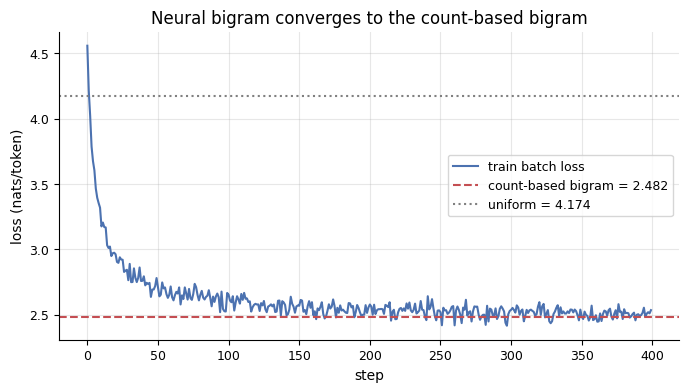

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history, color="#4C72B0", label="train batch loss")
ax.axhline(val_nll, color="#C44E52", linestyle="--", label=f"count-based bigram = {val_nll:.3f}")
ax.axhline(math.log(vocab_size), color="gray", linestyle=":", label=f"uniform = {math.log(vocab_size):.3f}")
ax.set_xlabel("step"); ax.set_ylabel("loss (nats/token)")
ax.set_title("Neural bigram converges to the count-based bigram")
ax.legend(); ax.grid(alpha=0.3)
plt.show()


### Sample from the learned model

The sampling loop is identical — just using the softmax'd logits instead of the counted probabilities. Output quality is identical too, as expected.


In [9]:
@torch.no_grad()
def sample_neural_bigram(W, n=200, seed=1):
    g = torch.Generator().manual_seed(seed)
    ix = torch.randint(0, vocab_size, (1,), generator=g).item()
    out = [ix]
    for _ in range(n - 1):
        logits = W[ix]
        probs = F.softmax(logits, dim=-1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        out.append(ix)
    return "".join(itos[i] for i in out)

print("--- sample from neural bigram (200 chars) ---")
print(sample_neural_bigram(W, n=200, seed=1))


--- sample from neural bigram (200 chars) ---
ggedor R!
INTIKIEr, llicone howonires hakn? iljurdorik,
t irlad harvaro BENCELLAyrindy m,
s s;
DLABorouth nd wig Esoloravend:
Le'd, qundemby ancteaYorerb:
Pave d s
Frouse.
YalMxs ware t:
D lon stlane,


### Look at what the network learned

The learned weight matrix `W`, after a softmax, should look a lot like our count-based `P`. Two heatmaps side by side:


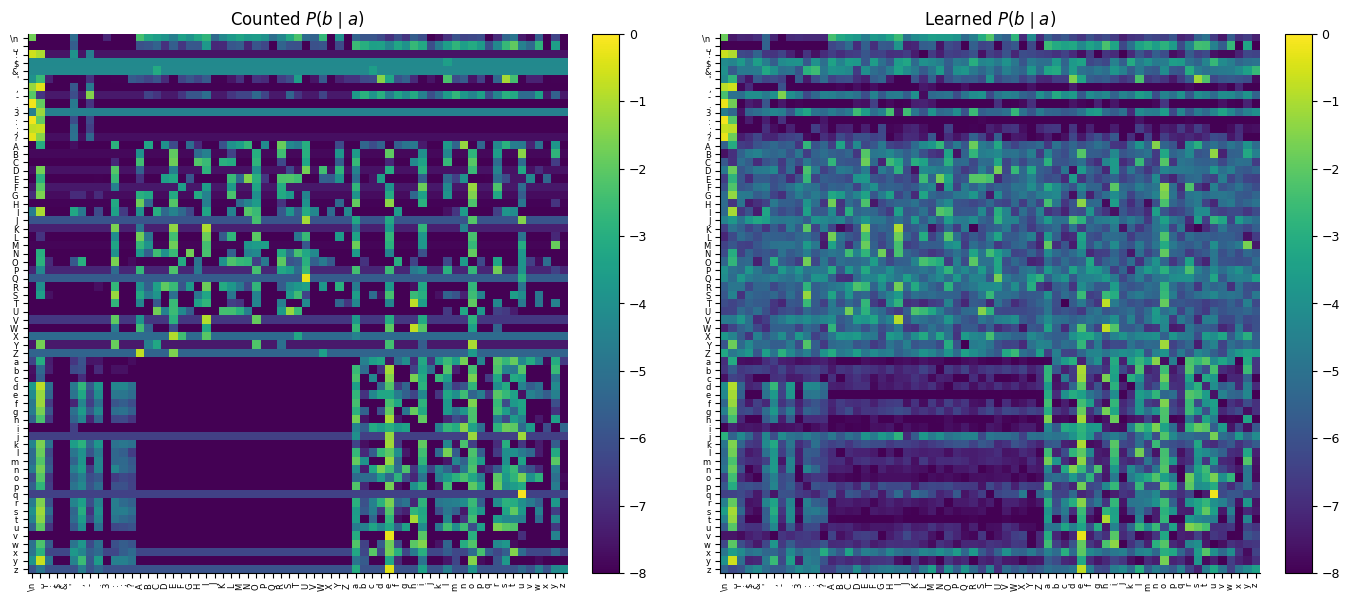

In [10]:
with torch.no_grad():
    P_neural = F.softmax(W, dim=-1)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, M, title in zip(axes, [P, P_neural], ["Counted $P(b\\mid a)$", "Learned $P(b\\mid a)$"]):
    im = ax.imshow(torch.log(M).numpy(), cmap="viridis", vmin=-8, vmax=0)
    ax.set_xticks(range(vocab_size)); ax.set_xticklabels(labels, rotation=90, fontsize=6)
    ax.set_yticks(range(vocab_size)); ax.set_yticklabels(labels, fontsize=6)
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


The two are visually indistinguishable. The neural network *re-derived* the counting statistics from gradient descent.

## The ceiling, seen clearly

Both models reach about **2.45 nats/token** on validation. Everything we do from here — RNNs, attention, transformers — is about *lowering that number* by letting the model condition on more than a single previous character. That's the entire game.

One more plot to make the ceiling visceral. Let's look at each row of our bigram table and compute its entropy — how uncertain the model is about the next character, given only the previous one. Even in the best case (row `q`, which almost always predicts `u`), it still assigns *some* mass elsewhere, because once in a while Shakespeare writes `q` followed by something non-`u`. For most rows the uncertainty is very high.


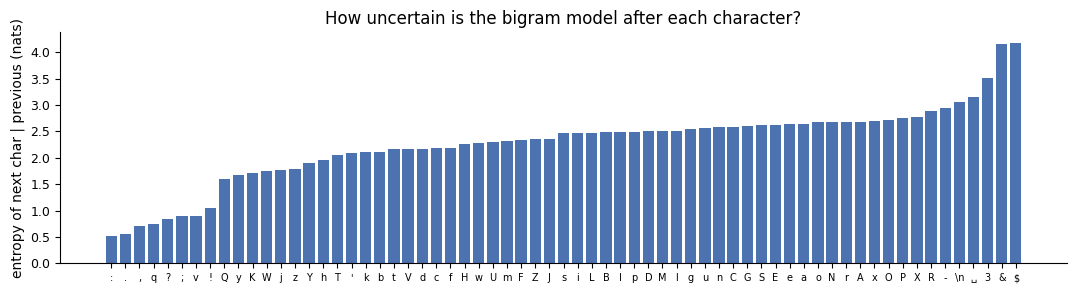

In [11]:
row_entropies = -(P * torch.log(P)).sum(dim=1)
order = torch.argsort(row_entropies).tolist()
fig, ax = plt.subplots(figsize=(13, 3))
ax.bar(range(vocab_size), row_entropies[order].numpy(), color="#4C72B0")
ax.set_xticks(range(vocab_size))
ax.set_xticklabels([viz._printable(chars[i]) for i in order], fontsize=7)
ax.set_ylabel("entropy of next char | previous (nats)")
ax.set_title("How uncertain is the bigram model after each character?")
plt.show()


Most rows are near 2.5–3.0 nats of uncertainty. The model almost always has a hard guess to make, because a single character just doesn't constrain what comes next. The fix is **context** — looking further back. That's tomorrow night's job.

## Gut recap

- A language model predicts $P(x_t \mid \text{context})$. Train by cross-entropy, generate by sampling.
- Counting bigrams and learning a bigram with gradient descent produce the same model. **Neural networks with a softmax head are learning (log-)counts.**
- The ceiling of bigrams is clear: you only see one character of context. Everything interesting in language lives further back than that.

**Next up:** [02 — RNNs and why they hit a wall →](02_rnns_and_their_limits.ipynb)
